In [12]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [13]:
from langchain_openai import ChatOpenAI

In [15]:
from langchain_core.messages import HumanMessage, AIMessage

In [17]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [18]:
model.invoke([
    HumanMessage(content="I am Rushi")
])

AIMessage(content="Hi Rushi! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0c710-9249-7f62-aee0-040c3933d7d4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 483, 'total_tokens': 488, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 464}})

In [19]:
model.invoke([
    HumanMessage(content="what is my name")
])

AIMessage(content="I don't know your name. As an AI, I don't have access to personal information about you, nor do I retain memory of past conversations.\n\nYou would need to tell me your name if you'd like me to know it!", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0c711-5f07-7b50-b5ef-b8f1c78c3d24-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 347, 'total_tokens': 352, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 295}})

In [31]:

model.invoke([
    HumanMessage(content="I am Rushi "),
    AIMessage(content="Hello, Rushi! How can I assist you today"),
    HumanMessage(content="What is my Name ")

])

AIMessage(content='Your name is Rushi.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0c718-f605-7830-9b88-59898adc71a3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 24, 'output_tokens': 43, 'total_tokens': 67, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 37}})

In [32]:

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import  MemorySaver

In [33]:

workflow = StateGraph(state_schema=MessagesState)

In [34]:
def call_model(state: MessagesState):
    respose = model.invoke(state["messages"])
    return {"messages": respose}

In [35]:
workflow.add_node("model", call_model)
workflow.add_edge(START, "model")
workflow.add_edge("model", END)

In [36]:
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

In [37]:
config = {"configurable": {"thread_id": "abc123"}}

In [38]:
query = " I am Rushi"
input_message = [HumanMessage(query)]
output = app.invoke({"messages": input_message}, config)

In [39]:
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Hello Rushi! Nice to meet you. How can I help you today?


In [40]:
query = "What is my name"
input_message = [HumanMessage(query)]
output = app.invoke({"messages": input_message}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Your name is Rushi! You just told me. 😊


In [41]:
config = {"configurable": {"thread_id": "abc124"}}
query = "What is my name"
input_message = [HumanMessage(query)]
output = app.invoke({"messages": input_message}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

As an AI, I don't have access to personal information about you, including your name. I don't know who you are unless you tell me.

If you'd like me to refer to you by a name during our conversation, feel free to tell me what it is!


In [42]:
for mem in memory.list(config):
    print(mem)

CheckpointTuple(config={'configurable': {'thread_id': 'abc124', 'checkpoint_ns': '', 'checkpoint_id': '1f1b6337-0c30-61f0-8001-d1ce5c759fb0'}}, checkpoint={'v': 2, 'ts': '2026-09-22T03:12:27.661156+00:00', 'id': '1f1b6337-0c30-61f0-8001-d1ce5c759fb0', 'channel_versions': {'__start__': '00000000000000000000000000000002.0.886173073670531', 'messages': '00000000000000000000000000000003.0.6147048903259258', 'start:model': '00000000000000000000000000000003.0.0142522825832343', 'model': '00000000000000000000000000000003.0.5453738627913375'}, 'versions_seen': {'__input__': {}, '__start__': {'__start__': '00000000000000000000000000000001.0.4844084015716287'}, 'model': {'start:model': '00000000000000000000000000000002.0.9393771562469604'}}, 'pending_sends': [], 'updated_channels': None, 'channel_values': {'messages': [HumanMessage(content='What is my name', additional_kwargs={}, response_metadata={}, id='070a18c0-c792-47e5-89ac-e2dba0f4d693'), AIMessage(content="As an AI, I don't have access to

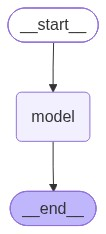

In [43]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))